# LAB:Movie Review

# Step 1- Built the review dataset

In [3]:
import pandas as pd
from transformers import pipeline
reviews_data = [
# Bollywood
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'An absolute masterpiece! Makes you laugh and cry. '
'Aamir Khan delivers one of his finest performances ever.'},
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'Overrated and preachy. The message was fine but '
'execution felt too theatrical and unrealistic.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Incredibly inspiring! Geeta and Babita brought tears '
'to my eyes. Best sports film ever made in India.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Good film but very long. Some scenes dragged unnecessarily.'},
# Hollywood
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Mind-bending and visually stunning. Nolan at his absolutebest.'},
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Too complicated. I had no idea what was happening half thetime.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'Perfect film. The class commentary is brilliant. Deserved everyOscar.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'I expected more from an Oscar winner. Ending felt rushed.'},
]
df = pd.DataFrame(reviews_data)

# Step 2- Analyze sentiment

In [4]:
# Load once — not inside a loop (that would reload weights every iteration)
sentiment = pipeline('sentiment-analysis',
model='distilbert-base-uncased-finetuned-sst-2-english')
# Batch all reviews at once — faster than one-by-one
results = sentiment(df['review'].tolist())
df['sentiment'] = [r['label'] for r in results] # POSITIVE / NEGATIVE
df['confidence'] = [r['score'] for r in results] # 0.0 to 1.0
# sentiment_score: 1.0 = very positive, 0.0 = very negative
df['sentiment_score'] = df['confidence'].where(
df['sentiment'] == 'POSITIVE',
1 - df['confidence']
)
print(df[['movie','sentiment','confidence']].to_string(index=False))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

    movie sentiment  confidence
 3 Idiots  POSITIVE    0.999879
 3 Idiots  NEGATIVE    0.999016
   Dangal  POSITIVE    0.999878
   Dangal  NEGATIVE    0.992343
Inception  POSITIVE    0.999849
Inception  NEGATIVE    0.999590
 Parasite  POSITIVE    0.999857
 Parasite  NEGATIVE    0.998913


# Step 3- Visualize results

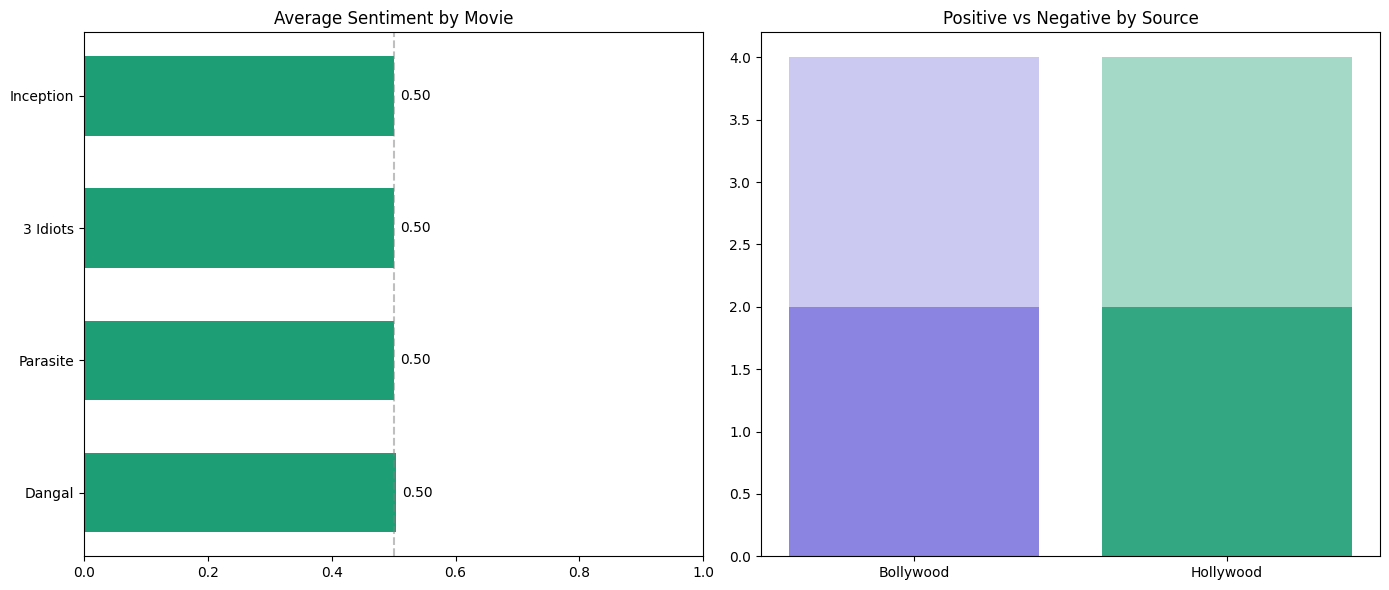

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Chart 1: Average sentiment score per movie
ax1 = axes[0]
movie_scores =df.groupby('movie')['sentiment_score'].mean().sort_values(ascending=False)
colours = ['#1D9E75' if v >= 0.5 else '#D85A30' for v in
movie_scores.values]
bars = ax1.barh(movie_scores.index, movie_scores.values, color=colours,
height=0.6)
ax1.set_xlim(0, 1)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Average Sentiment by Movie')
for bar, val in zip(bars, movie_scores.values):
  ax1.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}',
  va='center')
# Chart 2: Positive vs Negative split by source
  ax2 = axes[1]
for source, colour in [('Bollywood','#7F77DD'), ('Hollywood','#1D9E75')]:
  subset = df[df['source'] == source]
  pos = (subset['sentiment']=='POSITIVE').sum()
  neg = (subset['sentiment']=='NEGATIVE').sum()
  ax2.bar(source, pos, color=colour, alpha=0.9)
  ax2.bar(source, neg, bottom=pos, color=colour, alpha=0.4)
  ax2.set_title('Positive vs Negative by Source')
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 4-Predict on new user input

In [6]:
def analyse_review(review_text, movie_name='Unknown'):
  result = sentiment(review_text)[0]
  label = result['label']
  conf = result['score']
  if label == 'POSITIVE':
    score = conf
    verdict = 'LOVED IT' if conf > 0.95 else 'LIKED IT'
  else:
    score = 1 - conf
    verdict = 'HATED IT' if conf > 0.95 else 'DISLIKED IT'
  print(f'Movie : {movie_name}')
  print(f'Verdict : {verdict}')
  print(f'Score : {score:.1%} positive')
  print(f'Review : {review_text[:80]}...')
  return {'movie': movie_name, 'verdict': verdict, 'score': score}
analyse_review(
'Rajkummar Rao was phenomenal. A raw, honest performance. '
'Easily the best Hindi film of the decade.',
'Stree'
)

Movie : Stree
Verdict : LOVED IT
Score : 100.0% positive
Review : Rajkummar Rao was phenomenal. A raw, honest performance. Easily the best Hindi f...


{'movie': 'Stree', 'verdict': 'LOVED IT', 'score': 0.9998749494552612}